# **Task 1: SLIC & Region Adjacency Graph (RAG) Merging**

**Completed Description:**
Generate **superpixels** using the SLIC method. Construct a **Region Adjacency Graph (RAG)** using superpixel adjacency. Merge **regions using a color similarity** threshold. Display the **Original Superpixels** and **RAG + Merged Segments**.

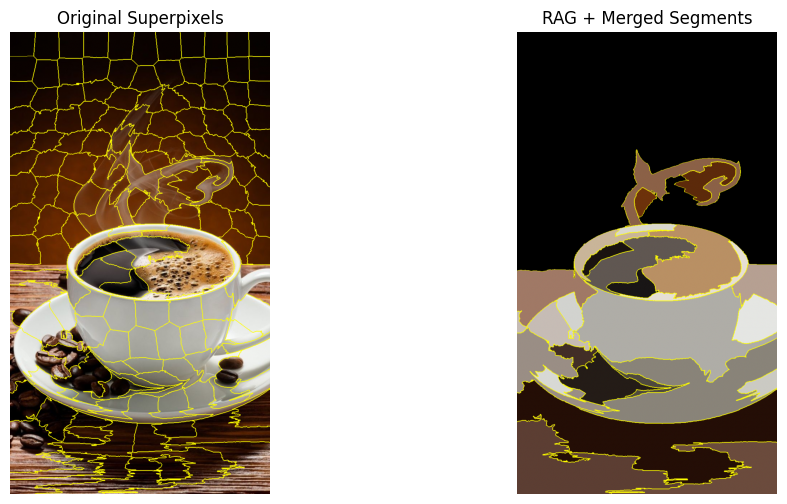

In [ ]:
from skimage import io, color
from skimage.segmentation import slic, mark_boundaries
from skimage.graph import rag_mean_color, cut_threshold
import matplotlib.pyplot as plt

# 1. Read the image
img = io.imread('coffee.jpg')

# 2. Generate superpixels using SLIC
labels = slic(img, n_segments=200, compactness=10, start_label=0)

# 3. Construct RAG
rag = rag_mean_color(img, labels)

# 4. Merge regions using a color similarity threshold
labels_merged = cut_threshold(labels, rag, thresh=35)
out = color.label2rgb(labels_merged, img, kind='avg')

# 5. Display the results
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.imshow(mark_boundaries(img, labels))
plt.title("Original Superpixels")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(out, labels_merged))
plt.title("RAG + Merged Segments")
plt.axis("off")
plt.show()